Import libraries and access the csv

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('https://raw.githubusercontent.com/vikasvittanala/basketball3021/refs/heads/nbaseason/NBA%20team%20stats%20csvs/nba_team_stats_00_to_23.csv')
df.head()

,teamstatspk,Team,games_played,wins,losses,win_percentage,Min,points,field_goals_made,field_goals_attempted,...,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season
0,0,Boston Celtics,82,64,18,0.780,3966,9887,3601,7396,...,3799,2207,979,557,538,304,1326,1416,930,2023-24
1,1,Denver Nuggets,82,57,25,0.695,3941,9418,3610,7279,...,3643,2415,1036,585,456,394,1489,1467,431,2023-24
2,2,Oklahoma City Thunder,82,57,25,0.695,3961,9847,3653,7324,...,3447,2223,1039,694,538,419,1545,1548,608,2023-24
3,3,Minnesota Timberwolves,82,56,26,0.683,3961,9264,3383,6974,...,3577,2184,1162,647,497,371,1544,1630,529,2023-24
4,4,LA Clippers,82,51,31,0.622,3941,9481,3473,7108,...,3523,2097,1078,640,413,384,1519,1537,269,2023-24


Structuring: filtering to remove unrelated columns

In [12]:
df2 = df[['teamstatspk', 'Team', 'win_percentage', 'Min', 'points', 'field_goals_made', 'field_goals_attempted', 'field_goal_percentage', 'three_pointers_made', 'three_pointers_attempted', 'three_point_percentage', 'free_throws_made', 'free_throw_attempted', 'free_throw_percentage', 'season']]
df2.head()

,teamstatspk,Team,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season
0,0,Boston Celtics,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,2023-24
1,1,Denver Nuggets,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,2023-24
2,2,Oklahoma City Thunder,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,2023-24
3,3,Minnesota Timberwolves,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,2023-24
4,4,LA Clippers,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,2023-24


Enriching: deriving new attributes 

In [13]:
# 3-point shooting volume: shows what proportion of team's shots are 3-pointers
df2['three_point_shooting_volume'] = df2['three_pointers_attempted'] / df2['field_goals_attempted']

# 3-point total contribution: shows ratio of how many points came from 3-pointers
df2['three_point_total_contribution'] = (df2['three_pointers_made'] * 3) / df2['points']
df2.head()

,teamstatspk,Team,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season,three_point_shooting_volume,three_point_total_contribution
0,0,Boston Celtics,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,2023-24,0.470795,0.409932
1,1,Denver Nuggets,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,2023-24,0.351697,0.305160
2,2,Oklahoma City Thunder,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,2023-24,0.382987,0.332081
3,3,Minnesota Timberwolves,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,2023-24,0.384428,0.335816
4,4,LA Clippers,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,2023-24,0.382527,0.327814


Cleaning: checking for null values

In [14]:
print(df2.isnull().values.any())

False


Exploration and initial graphs

In [15]:
df2.describe() # Metadata

,teamstatspk,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,three_point_shooting_volume,three_point_total_contribution
count,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000
mean,357.500000,0.499784,3888.927374,8230.385475,3062.220670,6716.244413,45.573743,654.132682,1828.652235,35.588408,1451.811453,1907.463687,76.198883,0.270103,0.234790
std,206.835684,0.148919,207.684720,712.154467,251.252302,446.747528,1.686295,244.858190,658.066269,1.894185,179.820064,242.163581,3.002977,0.088967,0.074731
min,0.000000,0.106000,3112.000000,5739.000000,2193.000000,5086.000000,40.800000,214.000000,641.000000,27.800000,889.000000,1198.000000,66.000000,0.100888,0.086047
25%,178.750000,0.390000,3951.000000,7838.500000,2931.750000,6490.750000,44.400000,466.000000,1302.500000,34.400000,1340.500000,1742.250000,74.400000,0.201132,0.177369
50%,357.500000,0.512000,3961.000000,8182.500000,3050.500000,6724.000000,45.500000,606.000000,1662.500000,35.500000,1452.000000,1908.000000,76.300000,0.251945,0.224294
75%,536.250000,0.610000,3971.000000,8641.500000,3208.500000,7018.000000,46.700000,845.500000,2367.250000,36.900000,1568.000000,2067.250000,78.200000,0.345889,0.294973
max,715.000000,0.890000,4016.000000,10110.000000,3855.000000,7739.000000,50.700000,1363.000000,3721.000000,41.600000,1977.000000,2587.000000,83.900000,0.519475,0.431281


In [16]:
df2["Team"].unique()

<StringArray>
[                   'Boston Celtics',                    'Denver Nuggets',
             'Oklahoma City Thunder',            'Minnesota Timberwolves',
                       'LA Clippers',                  'Dallas Mavericks',
                   'New York Knicks',                   'Milwaukee Bucks',
              'New Orleans Pelicans',                      'Phoenix Suns',
               'Cleveland Cavaliers',                    'Indiana Pacers',
                'Los Angeles Lakers',                     'Orlando Magic',
                'Philadelphia 76ers',             'Golden State Warriors',
                        'Miami Heat',                  'Sacramento Kings',
                   'Houston Rockets',                     'Chicago Bulls',
                     'Atlanta Hawks',                     'Brooklyn Nets',
                         'Utah Jazz',                 'Memphis Grizzlies',
                   'Toronto Raptors',                 'San Antonio Spurs',
           

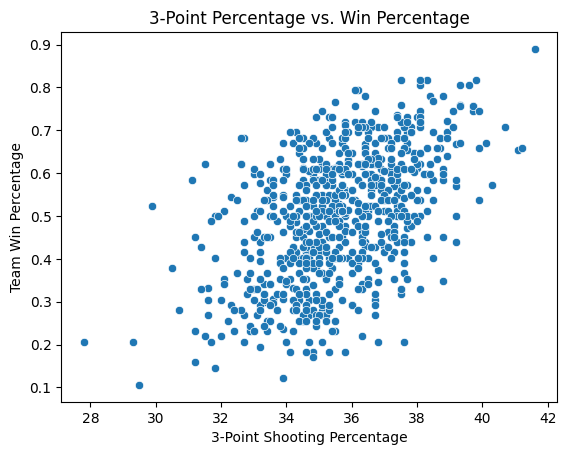

In [17]:
sns.scatterplot(data=df2, x='three_point_percentage', y='win_percentage')
plt.title('3-Point Percentage vs. Win Percentage')
plt.xlabel('3-Point Shooting Percentage')
plt.ylabel('Team Win Percentage')
plt.show()

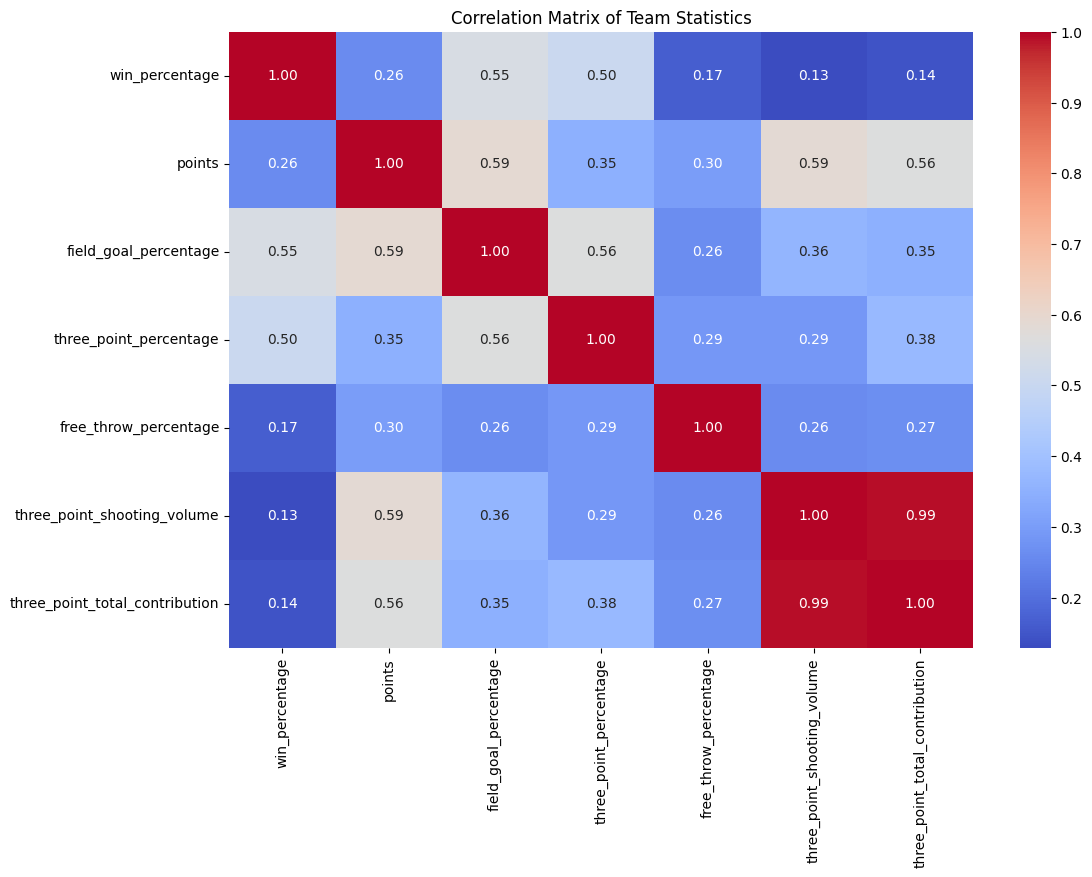

In [18]:
cols_of_interest = ['win_percentage', 'points', 'field_goal_percentage', 'three_point_percentage', 'free_throw_percentage', 'three_point_shooting_volume', 'three_point_total_contribution']
corr_submatrix = df2[cols_of_interest].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_submatrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Team Statistics')
plt.show()

Save cleaned dataframe to new csv

In [19]:
import os
df2.to_csv('data/nbaseason_cleaned.csv', index=False)